# Ablation study — progress monitor

Scans `out/<mode>/<label>/<run_id>/` and shows, live:

1. **Runs done per prop** — how many *finished* runs each prop has vs the target (e.g. Prop03 = 3/3 **done**, Prop08 = 2/3 still going). A **TIMEOUT** (the 12 h global-wall hit) counts as a finished run — it's a completed attempt with a terminal outcome, not something we re-run.
2. **Wall time for every run** — one bar per run.
   - **Finished** runs (SUCCESS/GAVEUP/FAIL) use `wall_sec` from `result.txt`.
   - **TIMEOUT** runs are pinned to the **12 h cap** (`WALL_LIMIT_HR`): the driver's global watchdog kills the run at exactly `t0 + 12 h`, and its `result.txt` `wall_sec` is a *stale per-round* value while the transcript span *undercounts* (the final hung build emits no records) — so neither is the true wall; the cap is.
   - **RUNNING** runs use `now − transcript_start` so the bar keeps growing until the run finishes.

Re-run all cells to refresh. **Kernel:** a Python with pandas + matplotlib — e.g. `~/.venvs/leaneuclid/bin/python`.

In [1]:
# ---- config ----------------------------------------------------------------
MODEL         = "opus"   # selects run folders whose label ends _<MODEL>
TARGET_RUNS   = 3        # a prop is "done" once it has this many FINISHED runs
WALL_LIMIT_HR = 12.0     # driver's global watchdog kills a run at exactly this many hours
OUT_BASE      = "/h/56/taddmao/code/autoform/DNA/reproducable_experiments/ablation_study/out"

import os, glob, json, re
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TERMINAL = run is no longer running (has a real final outcome). TIMEOUT = 12h wall hit.
TERMINAL    = {"SUCCESS", "GAVEUP", "FAIL", "TIMEOUT"}
RESULT_COL  = {"SUCCESS": "#2ca02c", "GAVEUP": "#ff7f0e", "FAIL": "#d62728",
               "TIMEOUT": "#9467bd", "RUNNING": "#9e9e9e"}
MODE_COL    = {"mymethod": "#1f77b4", "ablated": "#ff7f0e"}
NOW         = datetime.now(timezone.utc)
print("reference 'now' =", NOW.isoformat())

reference 'now' = 2026-07-21T23:02:31.164709+00:00


In [2]:
# ---- helpers ---------------------------------------------------------------
def parse_result(path):
    """result.txt -> dict of its 'key: value' lines."""
    d = {}
    for line in open(path):
        k, sep, v = line.partition(":")
        if sep:
            d[k.strip()] = v.strip()
    return d

def transcript_span(tpath):
    """(start, end) UTC datetimes from a transcript.jsonl, or (None, None)."""
    start = end = None
    try:
        with open(tpath) as f:
            for line in f:
                if '"timestamp"' not in line:
                    continue
                try:
                    ts = json.loads(line).get("timestamp")
                except Exception:
                    continue
                if not ts:
                    continue
                dt = datetime.fromisoformat(ts.replace("Z", "+00:00"))
                if start is None or dt < start:
                    start = dt
                if end is None or dt > end:
                    end = dt
    except FileNotFoundError:
        pass
    return start, end

In [3]:
# ---- discover every run (finished OR still running) ------------------------
rows = []
for run_dir in glob.glob(os.path.join(OUT_BASE, "*", f"*_{MODEL}", "*")):
    if not os.path.isdir(run_dir):
        continue
    parts  = run_dir.rstrip(os.sep).split(os.sep)
    mode   = parts[-3]            # e.g. ablated / mymethod
    label  = parts[-2]            # e.g. Book1_Prop03_opus
    run_id = parts[-1]            # e.g. 20260719-193910-fab15842

    rpath = os.path.join(run_dir, "result.txt")
    d      = parse_result(rpath) if os.path.exists(rpath) else {}
    result = d.get("result", "RUNNING").upper()   # no result.txt yet => RUNNING
    finished = result in TERMINAL                  # TERMINAL includes TIMEOUT

    # The local transcript.jsonl is only copied into the run dir when the run
    # FINISHES; while a run is RUNNING its transcript lives at the live session
    # path recorded in result.txt's 'transcript:' field. Read whichever exists.
    tpath = os.path.join(run_dir, "transcript.jsonl")
    if not os.path.exists(tpath):
        tpath = d.get("transcript", tpath)
    start, end = transcript_span(tpath)

    # wall time, by outcome:
    #   TIMEOUT  -> pin to the 12h cap. The global watchdog kills the run at
    #              exactly t0 + WALL_LIMIT, so 12h IS the true wall. result.txt's
    #              wall_sec is a stale per-round value and the transcript span
    #              undercounts (the final hung build emits no records) -> use neither.
    #   finished -> result.txt's final wall_sec.
    #   running  -> now - transcript_start (result.txt wall_sec is stale).
    wall_final = pd.to_numeric(d.get("wall_sec"), errors="coerce")
    if result == "TIMEOUT":
        wall_sec, wall_src = WALL_LIMIT_HR * 3600.0, "12h cap"
    elif finished and not np.isnan(wall_final):
        wall_sec, wall_src = float(wall_final), "result.txt"
    elif start is not None:
        wall_sec, wall_src = (NOW - start).total_seconds(), "now - transcript_start"
    else:
        wall_sec, wall_src = np.nan, "unknown"

    m = re.search(r"Prop0*(\d+)", label)
    propnum = int(m.group(1)) if m else -1

    rows.append(dict(
        mode=mode, label=label, run_id=run_id, propnum=propnum,
        prop_label=f"P{propnum}", result=result, finished=finished,
        timeout=(result == "TIMEOUT"),
        wall_sec=wall_sec, wall_min=wall_sec / 60.0, wall_hr=wall_sec / 3600.0, wall_src=wall_src,
        start=start, end=end,
    ))

df = pd.DataFrame(rows).sort_values(["mode", "propnum", "run_id"]).reset_index(drop=True)
print(f"{len(df)} runs across modes={sorted(df['mode'].unique()) if not df.empty else []}")
if not df.empty:
    print("outcomes:", df["result"].value_counts().to_dict())
df[["mode", "prop_label", "run_id", "result", "finished", "wall_hr", "wall_src"]] if not df.empty else df

39 runs across modes=['ablated', 'mymethod']
outcomes: {'SUCCESS': 22, 'TIMEOUT': 11, 'RUNNING': 6}


,mode,prop_label,run_id,result,finished,wall_hr,wall_src
0,ablated,P3,20260719-193910-fab15842,SUCCESS,True,0.069541,result.txt
1,ablated,P3,20260719-194334-95d75e25,SUCCESS,True,0.058090,result.txt
2,ablated,P3,20260719-194714-c7332038,SUCCESS,True,0.057399,result.txt
3,ablated,P6,20260719-193910-deed27fd,SUCCESS,True,0.211798,result.txt
4,ablated,P6,20260719-195213-a92accb8,SUCCESS,True,0.447239,result.txt
5,ablated,P6,20260720-012015-419d0e98,SUCCESS,True,0.239025,result.txt
6,ablated,P12,20260719-193910-80d83b18,SUCCESS,True,0.161429,result.txt
7,ablated,P12,20260719-194927-a2ebf3b2,SUCCESS,True,0.191030,result.txt
8,ablated,P12,20260719-200109-fdab2876,SUCCESS,True,0.423906,result.txt
9,ablated,P18,20260719-193910-05682b81,SUCCESS,True,0.258791,result.txt


In [4]:
# ---- per-prop progress: finished vs target ---------------------------------
def summarize(df):
    recs = []
    for (mode, propnum, label), x in df.groupby(["mode", "propnum", "prop_label"]):
        n_fin = int(x["finished"].sum())
        n_to  = int(x["timeout"].sum())
        recs.append(dict(
            mode=mode, propnum=propnum, prop_label=label,
            n_runs=len(x), n_finished=n_fin, n_timeout=n_to, n_running=len(x) - n_fin,
            n_success=int((x["result"] == "SUCCESS").sum()),
            done=n_fin >= TARGET_RUNS,
            progress=f"{n_fin}/{TARGET_RUNS}",
        ))
    return pd.DataFrame(recs).sort_values(["mode", "propnum"]).reset_index(drop=True)

summ = summarize(df) if not df.empty else pd.DataFrame()
summ

,mode,propnum,prop_label,n_runs,n_finished,n_timeout,n_running,n_success,done,progress
0,ablated,3,P3,3,3,0,0,3,True,3/3
1,ablated,6,P6,3,3,0,0,3,True,3/3
2,ablated,12,P12,3,3,0,0,3,True,3/3
3,ablated,18,P18,3,3,0,0,3,True,3/3
4,ablated,20,P20,3,2,2,1,0,False,2/3
5,ablated,27,P27,3,2,1,1,1,False,2/3
6,ablated,30,P30,3,2,2,1,0,False,2/3
7,ablated,36,P36,3,2,2,1,0,False,2/3
8,ablated,45,P45,3,2,2,1,0,False,2/3
9,ablated,47,P47,3,2,2,1,0,False,2/3


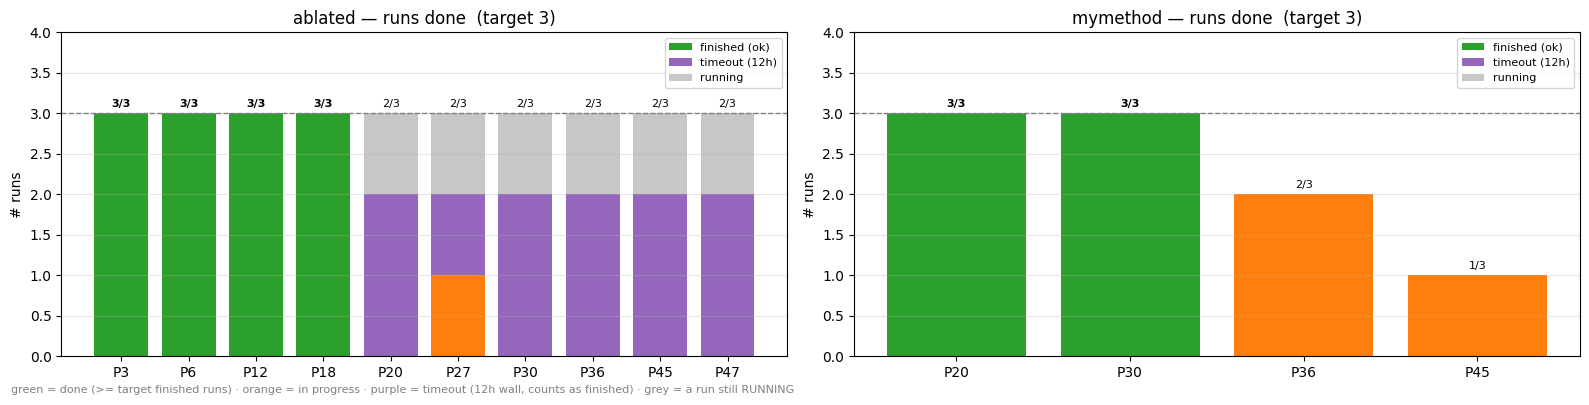

In [5]:
# ---- PLOT 1: runs done per prop (one subplot per mode) ---------------------
# Bars stack, bottom -> top:  OK-finished (green if prop done, else orange)
#                             + TIMEOUT (purple, the 12h wall)
#                             + RUNNING (grey).
if not summ.empty:
    modes = sorted(summ["mode"].unique())
    fig, axes = plt.subplots(1, len(modes),
                             figsize=(max(5, 0.6 * summ["propnum"].nunique() + 2) * len(modes), 4),
                             squeeze=False)
    for ax, mode in zip(axes[0], modes):
        s = summ[summ["mode"] == mode].sort_values("propnum")
        x = np.arange(len(s))
        n_ok = s["n_finished"] - s["n_timeout"]          # terminal, non-timeout
        ok_col = ["#2ca02c" if d else "#ff7f0e" for d in s["done"]]
        ax.bar(x, n_ok, color=ok_col, label="finished (ok)")
        ax.bar(x, s["n_timeout"], bottom=n_ok, color=RESULT_COL["TIMEOUT"], label="timeout (12h)")
        ax.bar(x, s["n_running"], bottom=s["n_finished"], color="#c7c7c7", label="running")
        ax.axhline(TARGET_RUNS, ls="--", color="gray", lw=1)
        for xi, (_, r) in zip(x, s.iterrows()):
            ax.text(xi, r["n_runs"] + 0.05, r["progress"], ha="center", va="bottom",
                    fontsize=8, fontweight="bold" if r["done"] else "normal")
        ax.set_xticks(x); ax.set_xticklabels(s["prop_label"], rotation=0)
        ax.set_ylabel("# runs"); ax.set_title(f"{mode} — runs done  (target {TARGET_RUNS})")
        ax.set_ylim(0, max(TARGET_RUNS, summ["n_runs"].max()) + 1)
        ax.grid(axis="y", alpha=0.3); ax.legend(loc="upper right", fontsize=8)
    fig.text(0.01, 0.005,
             "green = done (>= target finished runs) · orange = in progress · "
             "purple = timeout (12h wall, counts as finished) · grey = a run still RUNNING",
             fontsize=8, color="gray")
    plt.tight_layout(); plt.show()
else:
    print("no runs found")

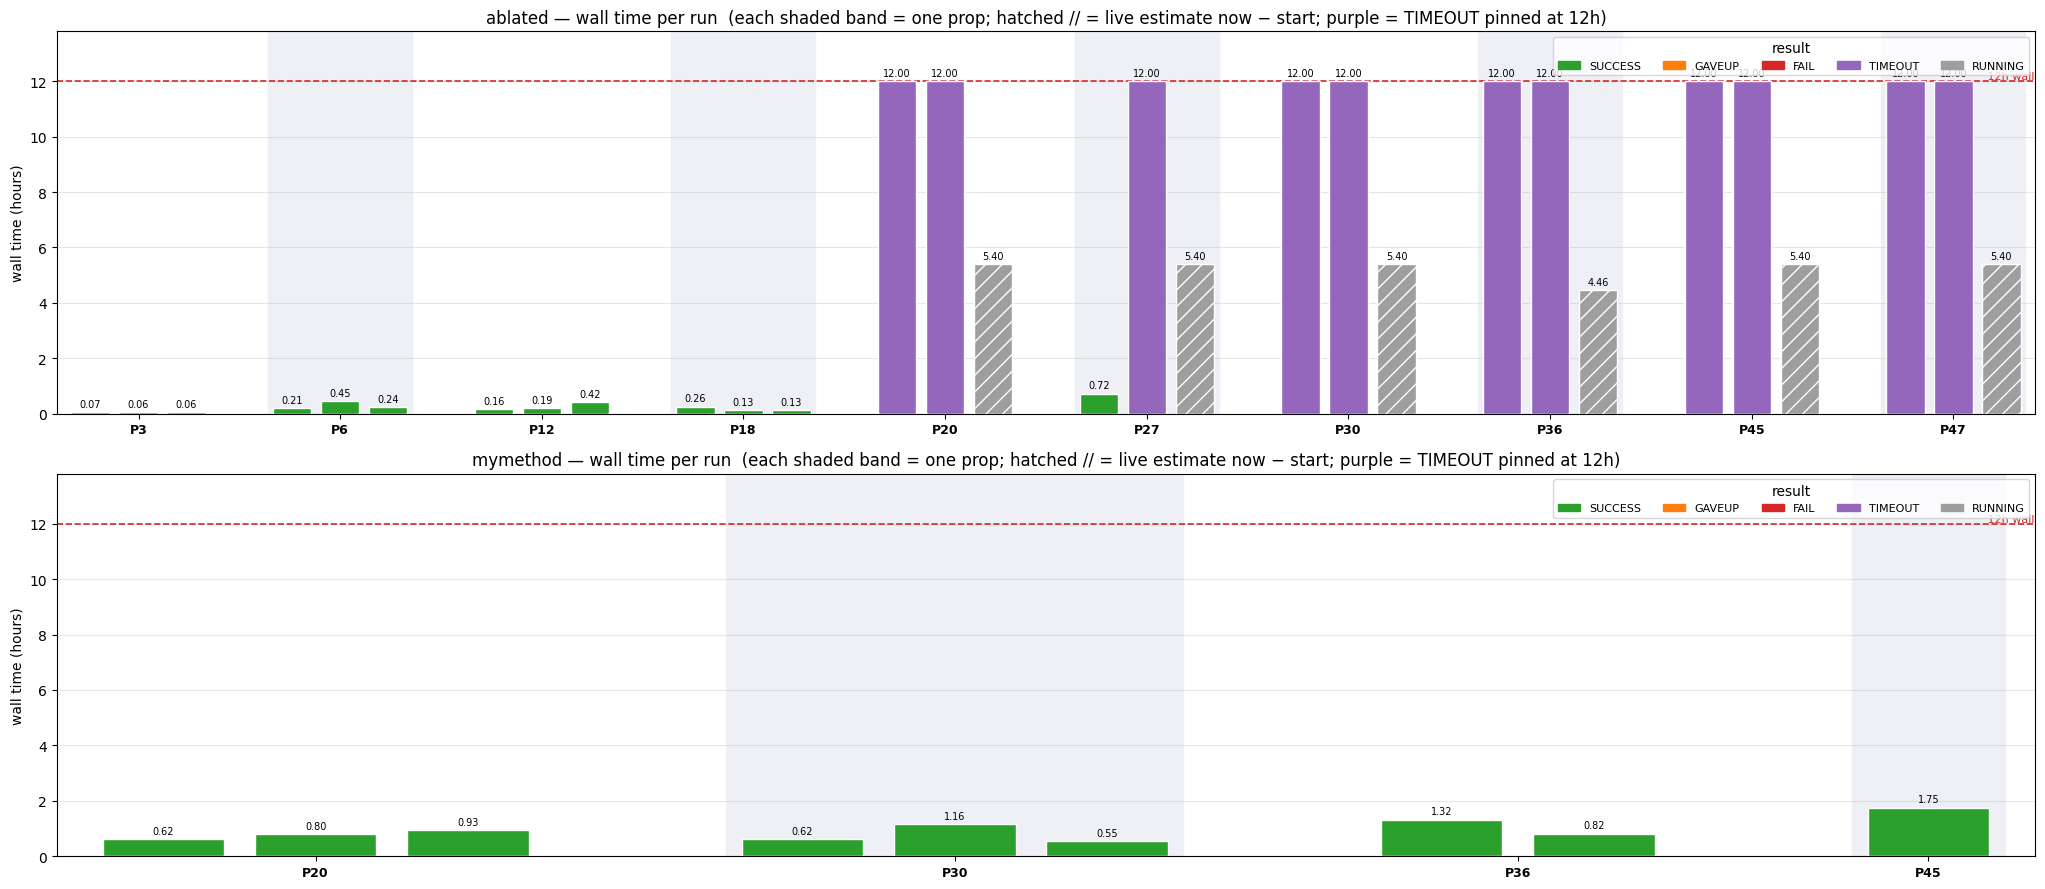

In [6]:
# ---- PLOT 2 (final): wall time for EVERY run, grouped by prop --------------
# One bar per run, in HOURS. Bar height by outcome:
#   SUCCESS/GAVEUP/FAIL -> result.txt wall_sec (solid)
#   TIMEOUT (purple)    -> pinned to the 12h cap (solid); the watchdog killed it
#                          there, so 12h is the true wall (see the discover cell)
#   RUNNING (grey)      -> now - transcript_start (hatched //, live estimate, grows)
# A dashed red line marks the 12h global wall. Each prop's runs sit in their OWN
# shaded band with a gap + a bold PN tick, so it is always unambiguous which
# bars belong to which proposition.
if not df.empty:
    GAP = 1.2   # empty x-space between one prop's group of bars and the next
    modes = sorted(df["mode"].unique())
    fig, axes = plt.subplots(len(modes), 1,
                             figsize=(max(9, 0.45 * len(df) + 3), 4.5 * len(modes)),
                             squeeze=False)
    for ax, mode in zip(axes[:, 0], modes):
        sub = df[df["mode"] == mode].sort_values(["propnum", "run_id"]).reset_index(drop=True)

        # lay out each prop's bars contiguously, with GAP between groups
        pos, group_spans, cursor = [], [], 0.0
        for pn, g in sub.groupby("propnum"):
            xs = [cursor + i for i in range(len(g))]
            pos.extend(xs)
            group_spans.append((pn, len(g), xs[0], xs[-1]))
            cursor = xs[-1] + 1 + GAP
        x = np.array(pos)
        wmax = float(np.nanmax(sub["wall_hr"].to_numpy())) if len(sub) else 1.0
        ymax = max(wmax, WALL_LIMIT_HR)          # always keep the 12h line in view

        # alternating shaded band behind each prop's group; bold PN on the axis
        centers, tlabels = [], []
        for k, (pn, n, x0, x1) in enumerate(group_spans):
            ax.axvspan(x0 - 0.5, x1 + 0.5, color="#eef0f6" if k % 2 else "#ffffff", zorder=0)
            centers.append((x0 + x1) / 2.0); tlabels.append(f"P{pn}")

        # the 12h global wall (TIMEOUT bars sit exactly on it)
        ax.axhline(WALL_LIMIT_HR, ls="--", color="#d62728", lw=1.2, zorder=2)
        ax.text(cursor - GAP - 0.3, WALL_LIMIT_HR, f" {WALL_LIMIT_HR:g}h wall",
                ha="right", va="bottom", fontsize=8, color="#d62728", zorder=5)

        colors = [RESULT_COL.get(r, "#333333") for r in sub["result"]]
        ax.bar(x, sub["wall_hr"], width=0.8, color=colors, zorder=3,
               hatch=["//" if not f else "" for f in sub["finished"]], edgecolor="white")
        for xi, w in zip(x, sub["wall_hr"]):
            if w == w:
                ax.text(xi, w + ymax * 0.01, f"{w:.2f}", ha="center", va="bottom",
                        fontsize=7, zorder=4)

        ax.set_xticks(centers)
        ax.set_xticklabels(tlabels, fontsize=9, fontweight="bold")
        ax.set_xlim(-0.7, cursor - GAP - 0.3)
        ax.set_ylim(0, ymax * 1.15)
        ax.set_ylabel("wall time (hours)")
        ax.set_title(f"{mode} — wall time per run  (each shaded band = one prop; "
                     f"hatched // = live estimate now − start; purple = TIMEOUT pinned at 12h)")
        ax.grid(axis="y", alpha=0.3, zorder=1)
        handles = [plt.Rectangle((0, 0), 1, 1, color=RESULT_COL[k]) for k in RESULT_COL]
        ax.legend(handles, list(RESULT_COL), title="result", fontsize=8, ncol=5, loc="upper right")
    plt.tight_layout(); plt.show()
else:
    print("no runs found")